# Régression linéaire : notations, optimum et vérification OLS

Ce TD reprend le CM2 (régression linéaire, fonction de perte, dérivée/minimum, solveur OLS) et le met en pratique sur le dataset **iowa** utilisé dans les TD 1 et 2. On manipule l'écriture vectorielle (produit scalaire), on cherche visuellement puis analytiquement le minimum de la fonction de perte, et on vérifie le résultat avec la méthode des moindres carrés (OLS).

### 0. Reprise du projet logements

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Fonction pour nettoyer les données (reprise du TD1)
def clean_data(data):
    # Supprime les lignes avec des valeurs manquantes dans la colonne SalePrice
    data.dropna(axis=0, subset=['SalePrice'], inplace=True)
    return data

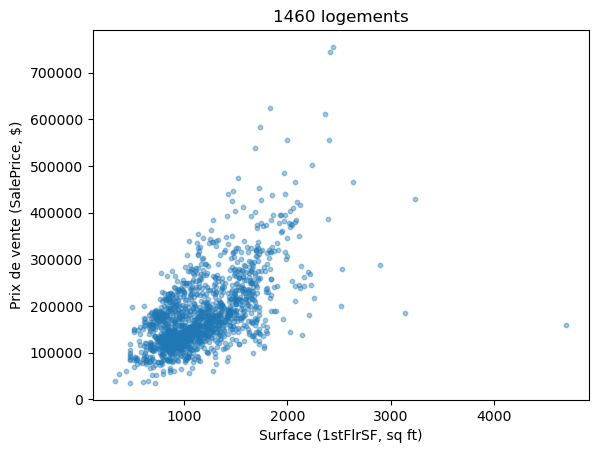

In [3]:
# Charger et nettoyer les données (reprise du TD1)
iowa_file_path = 'data/iowa_data.csv'
home_data = pd.read_csv(iowa_file_path)
home_data = clean_data(home_data)

# On se concentre sur une seule variable explicative, comme dans l'exemple du cours :
# x = surface du rez-de-chaussée (1stFlrSF), t = prix de vente (SalePrice)
x = home_data["1stFlrSF"]
t = home_data["SalePrice"]

# On visualise ces données
fig, ax = plt.subplots()
ax.scatter(x, t, s=10, alpha=0.4)
ax.set_xlabel('Surface (1stFlrSF, sq ft)')
ax.set_ylabel('Prix de vente (SalePrice, $)')
ax.set_title(f'{len(x)} logements')
plt.show()

## 1. Notations vectorielles (produit scalaire)

On modélise le prix comme une fonction linéaire de la surface : $f_w(x) = w_0 + w_1 x$. En ajoutant la coordonnée constante $x_0=1$, on écrit $\mathbf{x}=(1,x)^\top$ (ici $D=1$) et $\mathbf{w}=(w_0,w_1)^\top$, ce qui donne l'écriture vectorielle

$$f_\mathbf{w}(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}.$$

In [4]:
# TODO -- Complétez les deux fonctions suivantes : elles doivent donner le même résultat.

def predict_scalar(x_i, w0, w1):
    # Calcul "à la main", sans produit scalaire
    y_i = w0 + w1 * x_i
    return y_i

def predict_vector(x_aug_i, w):
    # Calcul par produit scalaire (x_aug_i = (1, x_i), w = (w0, w1))
    y_i = x_aug_i @ w
    return y_i

# Test sur les 5 premiers logements
w0, w1 = 20000.0, 100.0
w = np.array([w0, w1])
for x_i in x[:5]:
    x_aug_i = np.array([1.0, x_i])
    y_scalar = predict_scalar(x_i, w0, w1)
    y_vector = predict_vector(x_aug_i, w)
    print(f'x={x_i:7.0f}  predict_scalar={y_scalar:10.1f}  predict_vector={y_vector:10.1f}  égal ? {np.isclose(y_scalar, y_vector)}')

x=    856  predict_scalar=  105600.0  predict_vector=  105600.0  égal ? True
x=   1262  predict_scalar=  146200.0  predict_vector=  146200.0  égal ? True
x=    920  predict_scalar=  112000.0  predict_vector=  112000.0  égal ? True
x=    961  predict_scalar=  116100.0  predict_vector=  116100.0  égal ? True
x=   1145  predict_scalar=  134500.0  predict_vector=  134500.0  égal ? True


In [6]:
# TODO -- Généralisez à l'ensemble des logements avec la forme matricielle X w.
# Construisez X_aug, la matrice augmentée dont chaque ligne est (1, x_i).
X_aug = np.column_stack([np.ones_like(x),x])  # shape (N, 2)

y_all = X_aug @ w

print(y_all[:5])
print(np.array([predict_scalar(x_i, w0, w1) for x_i in x[:5]]))

[105600. 146200. 112000. 116100. 134500.]
[105600. 146200. 112000. 116100. 134500.]


**Question.** Pourquoi ajoute-t-on la coordonnée constante $x_0=1$ ? Que représente $w_0$ géométriquement pour la droite $f_w(x)=w_0+w_1x$ ?

## 2. Fonction de perte (MSE)

Pour comparer différents modèles $(w_0,w_1)$, on mesure l'écart entre les prédictions $y_n=f_\mathbf{w}(x_n)$ et les prix réels $t_n$ à l'aide de l'erreur quadratique moyenne :

$$E(\mathbf{w}) = \frac{1}{N}\sum_{n=1}^N (y_n - t_n)^2$$

In [7]:
# TODO -- Complétez la fonction de perte MSE.
def MSE(y, t):
    err = (y-t) **2
    return np.sum(err) / t.size

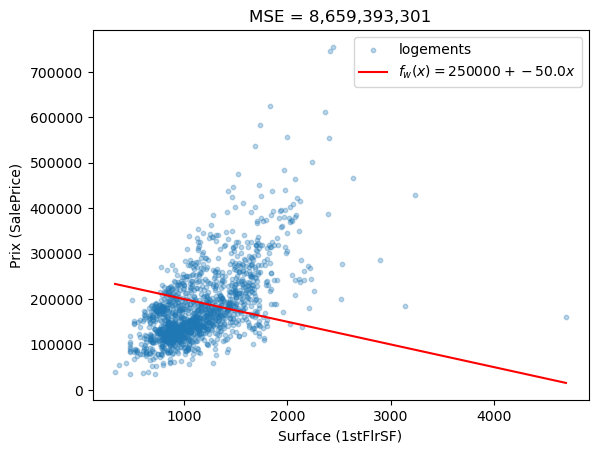

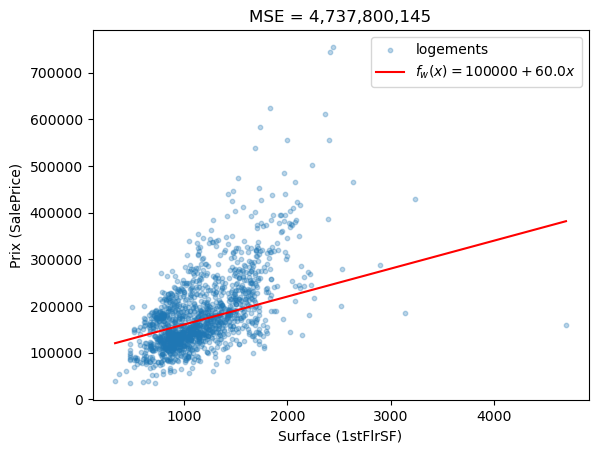

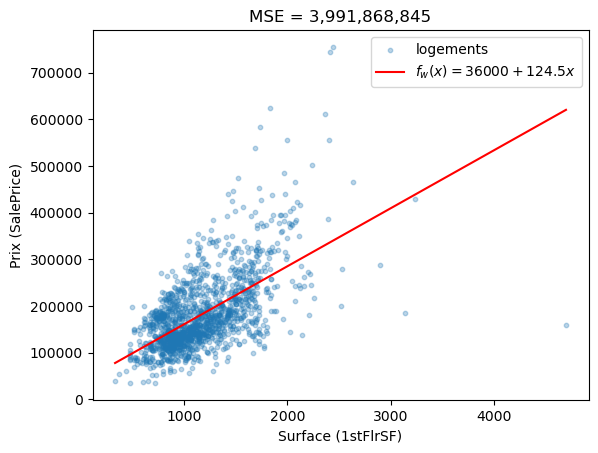

In [20]:
def plot_model(w0, w1, x=x, t=t):
    y = w0 + w1 * x
    loss = MSE(y, t)
    fig, ax = plt.subplots()
    ax.scatter(x, t, s=10, alpha=0.3, label='logements')
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, w0 + w1 * x_line, 'r-', label=f'$f_w(x)={w0:.0f}+{w1:.1f}x$')
    ax.set_xlabel('Surface (1stFlrSF)'); ax.set_ylabel('Prix (SalePrice)')
    ax.set_title(f'MSE = {loss:,.0f}')
    ax.legend()
    plt.show()
    return loss

# TODO -- Choisissez 3 couples (w0, w1) : un qui semble clairement mauvais,
# un qui semble raisonnable, un intermédiaire. Comparez leurs pertes.
for (w0, w1) in [(250000, -50.0), (100000, 60.0), (36000, 124.5)]:
    plot_model(w0, w1)

**Question.** D'après les pertes calculées, quel couple $(w_0,w_1)$ semble le meilleur ? Est-ce cohérent avec ce que vous observez visuellement sur le nuage de points ?

## 3. Chercher l'optimum : dérivée et minimum

### 3.1 Une seule variable à la fois

On considère $w_1$ fixé et on regarde comment $E$ varie en fonction du seul paramètre $w_0$ :

$$E(w_0) = \frac{1}{N}\sum_{n=1}^N (w_0 + w_1 x_n - t_n)^2.$$

C'est une fonction d'une seule variable : on peut donc en chercher le minimum avec sa dérivée (comme vu au lycée).

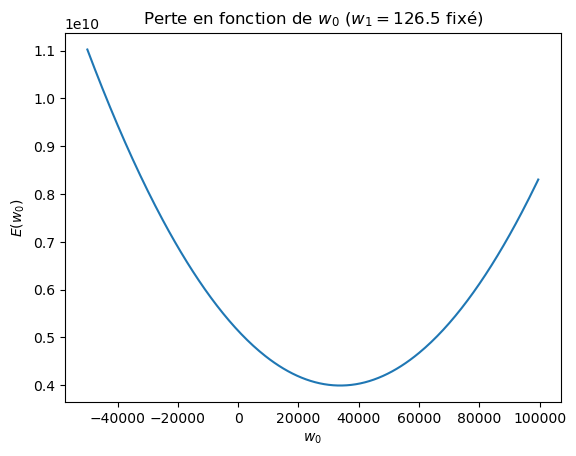

In [ ]:
def loss(w0, w1, x=x, t=t):
    y = w0 + w1 * x
    return MSE(y, t)

w1_fixed = 124.5  # reprenez une des valeurs de w1 essayées dans la partie 2
w0_range = np.arange(-50000.0, 100000.0, 500.0)
E_values = np.array([loss(w0, w1_fixed) for w0 in w0_range])

fig, ax = plt.subplots()
ax.plot(w0_range, E_values)
ax.set_xlabel('$w_0$'); ax.set_ylabel('$E(w_0)$')
ax.set_title(f'Perte en fonction de $w_0$ ($w_1={w1_fixed}$ fixé)')
plt.show()

**Question.** À la lecture du graphique, autour de quelle valeur de $w_0$ se situe le minimum ?

Sur papier : calculez $\dfrac{dE}{dw_0}$ et résolvez $\dfrac{dE}{dw_0}=0$. Vous devriez obtenir une expression fermée $w_0^*$ en fonction de $w_1$ et des moyennes $\bar{x}$ et $\bar{t}$.

In [21]:
def w0_star(w1, x=x, t=t):
    # TODO -- Implémentez la formule fermée trouvée sur papier
    w0 = t.mean() - w1 * x.mean() 
    return w0

w0_analytic = w0_star(w1_fixed)
print(f'w0* (formule analytique)              = {w0_analytic:.1f}')
print(f'w0 au minimum du graphique (approx.)   = {w0_range[np.argmin(E_values)]:.1f}')

w0* (formule analytique)              = 33848.9
w0 au minimum du graphique (approx.)   = 34000.0


### 3.2 Les deux variables ensemble : la surface de perte $E(w_0,w_1)$

En pratique, on cherche le minimum simultanément sur $w_0$ **et** $w_1$. $E$ devient alors une fonction de deux variables que l'on peut visualiser en surface 3D ou en courbes de niveau.

In [22]:
# Fonctions d'affichage (même principe que draw_2D_function dans TD1-Math)
def draw_loss_surface(w0_mesh, w1_mesh, E_mesh):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(w0_mesh, w1_mesh, E_mesh, cmap='viridis')
    ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('E(w0,w1)')
    ax.set_title('Surface de perte')
    plt.show()

def draw_loss_contour(w0_mesh, w1_mesh, E_mesh):
    fig, ax = plt.subplots()
    fig.set_size_inches(7, 7)
    pos = ax.contourf(w0_mesh, w1_mesh, E_mesh, levels=50, cmap='hot')
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel('w0'); ax.set_ylabel('w1')
    ax.contour(w0_mesh, w1_mesh, E_mesh, levels=20, cmap='winter')
    plt.show()

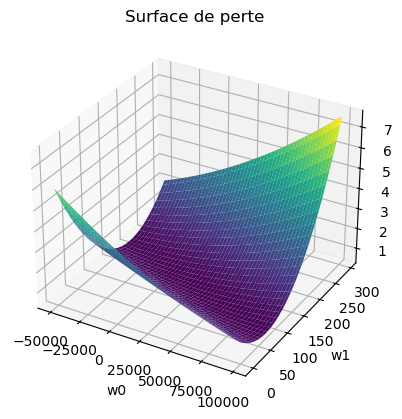

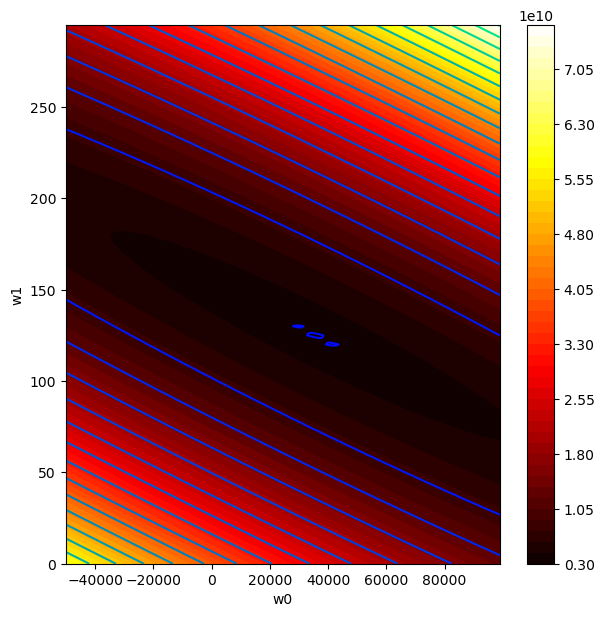

In [24]:
# TODO -- Construisez une grille de valeurs (w0, w1) et calculez E(w0,w1) sur chaque point.
# Ajustez les plages ci-dessous si le minimum semble se situer au bord de la grille.
w0_grid = np.arange(-50000.0, 100000.0, 1000.0)
w1_grid = np.arange(0.0, 300.0, 5.0)
w0_mesh, w1_mesh = np.meshgrid(w0_grid, w1_grid)

# Astuce : E_mesh[i, j] = loss(w0_grid[j], w1_grid[i])
E_mesh = np.array([[loss(w0,w1) for w0 in w0_grid] for w1 in w1_grid])   # tableau 2D, même forme que w0_mesh et w1_mesh

draw_loss_surface(w0_mesh, w1_mesh, E_mesh)
draw_loss_contour(w0_mesh, w1_mesh, E_mesh)

**Question.** Repérez sur les graphiques (le creux de la surface / le centre des courbes de niveau) la zone où $E$ semble minimale. Lisez approximativement les coordonnées $(w_0,w_1)$ correspondantes.

In [ ]:
# TODO -- Retrouvez automatiquement le minimum de la grille
# (voir np.argmin et np.unravel_index)
i_min, j_min = np.unravel_index(np.argmin(E_mesh), E_mesh.shape)
w0_grid_min = w0_mesh[i_min, j_min]
w1_grid_min = w1_mesh[i_min, j_min]
print(f'Minimum (grille) : w0 = {w0_grid_min:.0f}, w1 = {w1_grid_min:.1f}, E = {E_mesh[i_min, j_min]:,.0f}')

## 4. Vérifier avec le solveur OLS

La recherche par grille est approximative et coûteuse. Comme vu en cours, on peut annuler directement les dérivées partielles de $E$ :

$$\frac{\partial E}{\partial w_0} \propto \sum_{n=1}^N \big\{(w_0+w_1x_n)-t_n\big\} = 0 \qquad
\frac{\partial E}{\partial w_1} \propto \sum_{n=1}^N \big\{(w_0+w_1x_n)-t_n\big\}\,x_n = 0$$

Sous forme matricielle, avec $X$ la matrice augmentée ($N$ lignes, colonnes $(1,x_n)$) et $t$ le vecteur des prix, cela revient à résoudre le système linéaire $X^\top X\, w = X^\top t$, dont la solution est $w^* = (X^\top X)^{-1} X^\top t$.

In [ ]:
# TODO -- Construisez la matrice augmentée X_aug (colonne de 1 puis colonne x),
# puis résolvez le système des équations normales X_aug^T X_aug w = X_aug^T t.
X_aug = ...
A = ...  # X_aug^T X_aug
b = ...  # X_aug^T t
w_star = np.linalg.solve(A, b)
print(f'w* (équations normales) : w0 = {w_star[0]:.1f}, w1 = {w_star[1]:.3f}')

In [ ]:
# TODO -- Implémentez la formule fermée w* = (X^T X)^-1 X^T t avec np.linalg.inv,
# et vérifiez qu'elle donne (presque) le même résultat que np.linalg.solve ci-dessus.
w_star_inv = ...
print(w_star_inv)
print(np.allclose(w_star, w_star_inv))

**Question.** Comparez `w_star` :
- à l'estimation lue sur la grille de la partie 3.2 (`w0_grid_min`, `w1_grid_min`) ;
- à `w0_star(w_star[1])` de la partie 3.1 (la formule analytique appliquée avec $w_1=w_1^*$).

Que constatez-vous ?

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x.reshape(-1, 1), t)

print(f'w* (équations normales) : w0 = {w_star[0]:.1f}, w1 = {w_star[1]:.3f}')
print(f'sklearn LinearRegression : w0 = {model.intercept_:.1f}, w1 = {model.coef_[0]:.3f}')

In [ ]:
plot_model(w_star[0], w_star[1])

## 5. Ouverture : vers la descente de gradient

Ici, avec $D=1$ variable explicative, inverser $X^\top X$ (une matrice $2\times2$) ne coûte rien. Mais si l'on utilise les 7 variables du TP1 ($D=7$), ou pire, un modèle à des milliards de paramètres comme GPT-4 ($D\sim10^{12}$), calculer $(X^\top X)^{-1}$ devient impossible. Il faut alors une méthode itérative pour approcher le minimum de $E$ sans jamais inverser de matrice : c'est l'objet du prochain TD, la **descente de gradient**.